# scRNA-seq Analysis Pipeline
Full pipeline from raw 10x data to DEGs and GO enrichment.
Swap `GENE_OF_INTEREST` and the gene signature lists for your own biology.

## 0. Imports & Config

In [2]:
import os
import sys
from pathlib import Path

def find_project_root(start):
    if (start / 'src').exists() and (start / 'notebooks').exists():
        return start
    for parent in start.parents:
        if (parent / 'src').exists() and (parent / 'notebooks').exists():
            return parent
    for child in start.iterdir():
        if child.is_dir() and (child / 'src').exists() and (child / 'notebooks').exists():
            return child
    return None

PROJECT_ROOT = find_project_root(Path().resolve())
if PROJECT_ROOT is None:
    raise RuntimeError('Could not find project root — make sure src/ and notebooks/ exist')

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip

from src.qc import plot_qc_metrics, filter_cells
from src.preprocessing import preprocess
from src.clustering import cluster
from src.analysis import GeneOfInterestAnalysis

%matplotlib inline
sc.settings.verbosity = 1

In [4]:
GENE_OF_INTEREST = 'CELSR2'

# demo path — combined raw counts that have already been QC'd, filtered, and clustered
H5AD_PATH = 'data/demo/demo_adata.h5ad'

# full run from raw 10x MTX files — see data/raw/README.md
# RAW_DIR = 'data/raw/GSE161529_RAW/'
# FEATURES_FILE = 'data/raw/GSE161529_features.tsv'

## Data
This analysis uses the GSE161529 breast cancer scRNA-seq dataset (Qian et al. 2020).

**Demo:** `data/demo/demo_adata.h5ad`...already QC'd, filtered, and clustered. Jump straight to Section 5.

**Full run from raw:** See `data/raw/README.md` for download instructions. Uncomment `RAW_DIR`/`FEATURES_FILE` in config and run Sections 1–4 instead.

## 1. Data Loading
Load ER+ primary tumor samples from raw 10x MTX files and concatenate.

> **Skipping for demo** — `demo_adata.h5ad` is already a concatenated, processed object. Run `adata = sc.read_h5ad(H5AD_PATH)` in Section 5 instead.

In [ ]:
# find only ER+ primary tumor samples — exclude lymph node
samples = [f.replace('-barcodes.tsv.gz', '')
           for f in os.listdir(RAW_DIR)
           if f.endswith('-barcodes.tsv.gz') and '_ER-' in f and '-LN' not in f]

print(f'Found {len(samples)} ER+ primary tumor samples:')
print(samples)

In [ ]:
# each sample needs its own features file — copy the shared one in
for sample in samples:
    dest = os.path.join(RAW_DIR, f'{sample}-features.tsv.gz')
    if not os.path.exists(dest):
        with open(FEATURES_FILE, 'rb') as f_in:
            content = f_in.read()
        with gzip.open(dest, 'wb') as f_out:
            f_out.write(content)
        print(f'Copied features for {sample}')

In [ ]:
adatas = {}
for sample in samples:
    try:
        adata_s = sc.read_10x_mtx(
            RAW_DIR, var_names='gene_symbols', prefix=f'{sample}-', cache=True
        )
        adata_s.var_names_make_unique()
        parts = sample.split('_')
        adata_s.obs['sample'] = sample
        adata_s.obs['patient'] = parts[1] if len(parts) > 1 else sample
        adatas[sample] = adata_s
        print(f'Loaded {sample}: {adata_s.n_obs} cells')
    except Exception as e:
        print(f'Skipping {sample}: {e}')

adata = ad.concat(adatas, label='sample', keys=list(adatas.keys()))
adata.var_names_make_unique()
print(f'Total: {adata.n_obs} cells, {adata.n_vars} genes')

## 2. QC
Plot QC metrics first, then filter low-quality cells based on what you see.

> **Skipping for demo** — `demo_adata.h5ad` already has QC metrics in `obs` and has been filtered. These cells show what the step looks like on fresh raw data.

In [ ]:
adata = plot_qc_metrics(adata)

In [ ]:
# tune thresholds based on the violin plots above
adata = filter_cells(
    adata,
    mt_threshold=20,
    ribo_threshold=40,
    min_genes=100,
    min_cells=10,
    upper_quantile=0.98,
    remove_doublets=True
)

## 3. Preprocessing
Normalize to total counts, log-transform, and subset to highly variable genes. Raw counts are stashed in `adata.layers['raw_counts']` before normalization.

> **Skipping for demo** — `demo_adata.h5ad` is already normalized and log-transformed.

In [ ]:
adata = preprocess(adata, HVG=2000)

## 4. Clustering
PCA → Harmony batch correction (by sample) → neighbors → UMAP → Leiden clustering. Check the PCA variance plot to tune `n_pcs`.

> **Skipping for demo** — `demo_adata.h5ad` already has `X_pca_harmony`, `X_umap`, and `leiden` computed.

In [ ]:
adata = cluster(
    adata,
    batch_key='sample',
    res=0.5,
    n_pcs=50
)

## 5. Exploratory Analysis
Load the demo object here and pick up from clustering.

In [5]:
# load demo — skip this if you ran Sections 1-4 above
adata = sc.read_h5ad(H5AD_PATH)
print(adata)

AnnData object with n_obs × n_vars = 98719 × 23276
    obs: 'sample', 'patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'leiden'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


In [6]:
analysis = GeneOfInterestAnalysis(adata, GENE_OF_INTEREST)

In [7]:
analysis.exploratory_plots(color=['leiden', 'sample', GENE_OF_INTEREST], state_name='full_dataset_UMAP')

<Figure size 2183.4x480 with 0 Axes>

In [8]:
analysis.plot_marker_genes(n_genes=5, state_name='full_dataset_markers')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


<Figure size 2560x2400 with 0 Axes>

## 6. Gene Scoring
Score cells for your gene of interest and relevant gene signatures. Edit lists to match your biology.

In [9]:
gene_list = [
    [GENE_OF_INTEREST],
    ['MKI67', 'TOP2A', 'PCNA', 'CDK1'], # proliferating
    ['NR2F1', 'CDKN1B', 'LIFR', 'BMPR2'], # dormant
    ['MGP', 'PEG10', 'ZFP36L1', 'XBP1'], # luminal progenitor
    ['RPL3', 'KRT19', 'KRT18', 'GATA3'], # luminal epithelial
    ['XBP1', 'HSPA5', 'DDIT3', 'ATF4'], # UPR / ER stress
]

name_list = [
    f"{GENE_OF_INTEREST}_score",
    'Proliferating',
    'Dormant',
    'Luminal_Progenitor',
    'Luminal_Epithelial',
    'UPR',
]

analysis.score_genes(gene_list=gene_list, name_list=name_list, vmax=1.0, state_name='full_dataset_scores')

<Figure size 1455.6x1440 with 0 Axes>

In [10]:
expr = adata[:, GENE_OF_INTEREST].X.toarray().flatten()
print(f'% cells expressing {GENE_OF_INTEREST}: {(expr > 0).mean() * 100:.2f}%')
print(f'Mean expression: {expr.mean():.4f}')
print(f'Max expression: {expr.max():.4f}')

% cells expressing CELSR2: 7.78%
Mean expression: 0.0335
Max expression: 2.1690


In [11]:
adata.obs[f'{GENE_OF_INTEREST}_expr'] = expr
result = adata.obs.groupby('leiden')[f'{GENE_OF_INTEREST}_expr'].agg(
    mean_expr='mean',
    pct_expressing=lambda x: (x > 0).mean() * 100
).round(3)
print(result.sort_values('pct_expressing', ascending=False))

        mean_expr  pct_expressing
leiden                           
8           0.074          21.354
13          0.081          18.076
14          0.066          16.594
0           0.051          13.907
16          0.033          13.514
2           0.051          10.381
15          0.015           9.836
6           0.034           8.980
5           0.037           4.004
7           0.027           3.679
9           0.015           1.847
4           0.010           1.630
3           0.009           1.427
11          0.007           0.815
10          0.004           0.724
12          0.002           0.162
1           0.002           0.157


/var/folders/dc/qf5jzxt16dv9gpygl51xbt6w0000gn/T/ipykernel_18577/642265155.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = adata.obs.groupby('leiden')[f'{GENE_OF_INTEREST}_expr'].agg(


In [12]:
analysis.plot_dotplot(
    var_names=[
        GENE_OF_INTEREST,
        'MKI67', 'TOP2A', 'PCNA', 'CDK1',
        'NR2F1', 'CDKN1B', 'LIFR', 'BMPR2'
    ],
    state_name='full_dataset_dotplot'
)

<Figure size 533x695 with 0 Axes>

## 7. Subset to Clusters of Interest
Based on the expression table and marker plots above, pick the clusters that express your gene and re-cluster.

In [13]:
# pick clusters based on expression table above
clusters_of_interest = ['0', '2', '8', '13', '14', '15', '16']

sub_analysis = analysis.subset_clusters(clusters_of_interest, res=0.5)

# save raw subset before re-clustering
sub_analysis.save_adata('adata_subset_raw')

/Users/rohith/Coding Hub/Projects/Generalizable_GeneOfInterest_scRNA-seq/src/analysis.py:101: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_sub, resolution=res)


Saved to data/adata_subset_raw.h5ad


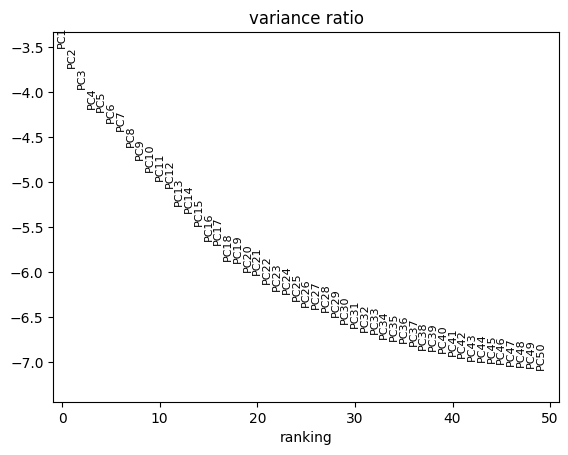

2026-09-03 02:31:59,219 - harmonypy - INFO - Iteration 1 of 10
2026-09-03 02:32:07,771 - harmonypy - INFO - Iteration 2 of 10
2026-09-03 02:32:17,361 - harmonypy - INFO - Converged after 2 iterations
/Users/rohith/Coding Hub/Projects/Generalizable_GeneOfInterest_scRNA-seq/src/clustering.py:35: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res)


<Figure size 640x480 with 0 Axes>

In [14]:
from src.clustering import cluster

adata_sub = sc.read_h5ad('data/adata_subset_raw.h5ad')
adata_sub = cluster(adata_sub, batch_key='sample', res=0.5)
sub_analysis = GeneOfInterestAnalysis(adata_sub, GENE_OF_INTEREST)

In [16]:
sub_analysis.exploratory_plots(color=['leiden', 'sample'], state_name='subset_UMAP')

<Figure size 1455.6x480 with 0 Axes>

In [17]:
sub_analysis.plot_marker_genes(n_genes=10, state_name='subset_markers')

<Figure size 2560x960 with 0 Axes>

In [18]:
sub_analysis.score_genes(gene_list=gene_list, name_list=name_list, vmax=1.7, state_name='subset_scores')

<Figure size 1455.6x1440 with 0 Axes>

In [19]:
sub_analysis.plot_dotplot(
    var_names=[
        GENE_OF_INTEREST,
        'MKI67', 'TOP2A', 'PCNA', 'CDK1',
        'NR2F1', 'CDKN1B', 'LIFR', 'BMPR2'
    ],
    state_name='subset_dotplot'
)

<Figure size 533x345 with 0 Axes>

## 8. Save Results

In [20]:
sub_analysis.save_deg_results(name='deg_results_subset')

Saved DEG results to results/tables/deg_results_subset.csv


In [21]:
sub_analysis.save_adata(name='adata_subset')

Saved to data/adata_subset.h5ad


## 9. GO Enrichment (optional)
Load the DEG CSV and run preranked GSEA on a cluster of interest.

In [22]:
from src.enrichment import run_enrichment, specific_enrichment

deg_df = pd.read_csv('results/tables/deg_results_subset.csv')
cluster_ids = deg_df['cluster'].unique()

for cluster_id in cluster_ids:
    prerank_results, results_df = run_enrichment(
        deg_df,
        cluster_id=int(cluster_id),
        state_name=f'cluster{cluster_id}_GSEA'
    )

2026-09-03 02:36:59,213 [WARNING] Duplicated values found in preranked stats: 0.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-03 02:37:47,050 [WARNING] Duplicated values found in preranked stats: 0.60% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-03 02:38:57,320 [WARNING] Duplicated values found in preranked stats: 0.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-03 02:39:47,397 [WARNING] Duplicated values found in preranked stats: 0.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-03 02:40:35,740 [WARNING] Duplicated values found in preranked stats: 0.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-03 02:41:25,956 [WARNING] Duplicated values found in preranked stats: 0.60% of genes
The order of those genes will be

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot enrichment curve for the top hit...unused for this demo
specific_enrichment(prerank_results, term=results_df['Term'].iloc[0])